# NYC Taxi Trip Duration — EDA

## Table of Contents
1. [Imports & Data Loading](#1.-Imports-&-Data-Loading)
2. [Initial Inspection](#2.-Initial-Inspection)
3. [Trip Duration Distribution](#3.-Trip-Duration-Distribution)
4. [Pickup Volume Over Time](#4.-Pickup-Volume-Over-Time)
5. [Categorical Feature Analysis](#5.-Categorical-Feature-Analysis)
6. [Datetime Feature Analysis](#6.-Datetime-Feature-Analysis)
7. [Geographical Analysis](#7.-Geographical-Analysis)
8. [Correlation Heatmap](#8.-Correlation-Heatmap)
9. [Weather EDA](#9.-Weather-EDA)
10. [OSRM Fastest-Route Data](#10.-OSRM-Fastest-Route-Data)
11. [Trip Duration vs. Total Travel Time — Curious Delays](#11.-Trip-Duration-vs.-Total-Travel-Time-—-Curious-Delays)
12. [Key Takeaways](#12.-Key-Takeaways)


## 1. Imports & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import folium

sns.set_theme(style="whitegrid", palette="deep", font_scale=1.05)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.titleweight"] = "bold"


In [2]:
df = pd.read_csv(r"C:\Users\pc\Desktop\Trip duration dataset\split\raw\train.csv")
df.head()

,id,vendor_id,pickup_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2793718,2,2016-06-08 07:36:19,1,-73.985611,40.735943,-73.980331,40.760468,N,1040
1,id3485529,2,2016-04-03 12:58:11,1,-73.978394,40.764351,-73.991623,40.749859,N,827
2,id1816614,2,2016-06-05 02:49:13,5,-73.989059,40.744389,-73.973381,40.748692,N,614
3,id1050851,2,2016-05-05 17:18:27,2,-73.990326,40.731136,-73.991264,40.748917,N,867
4,id0140657,1,2016-05-12 17:43:38,4,-73.789497,40.646675,-73.987137,40.759232,N,4967


## 2. Initial Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   id                  1000000 non-null  object 
 1   vendor_id           1000000 non-null  int64  
 2   pickup_datetime     1000000 non-null  object 
 3   passenger_count     1000000 non-null  int64  
 4   pickup_longitude    1000000 non-null  float64
 5   pickup_latitude     1000000 non-null  float64
 6   dropoff_longitude   1000000 non-null  float64
 7   dropoff_latitude    1000000 non-null  float64
 8   store_and_fwd_flag  1000000 non-null  object 
 9   trip_duration       1000000 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 76.3+ MB


In [4]:
df.describe()

,vendor_id,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1.000000e+06
mean,1.534793,1.665353,-73.973475,40.750947,-73.973421,40.751829,9.548850e+02
std,0.498788,1.315723,0.065404,0.033745,0.065432,0.035782,3.882070e+03
min,1.000000,0.000000,-121.933342,34.359695,-121.933304,34.359695,1.000000e+00
25%,1.000000,1.000000,-73.991852,40.737372,-73.991341,40.735928,3.970000e+02
50%,2.000000,1.000000,-73.981728,40.754131,-73.979767,40.754551,6.620000e+02
75%,2.000000,2.000000,-73.967346,40.768379,-73.963036,40.769833,1.074000e+03
max,2.000000,7.000000,-61.335529,51.881084,-61.335529,43.921028,2.227612e+06


We can observe:

1. `pickup_datetime` has a complex format — we need to extract hour, day, month from it
2. `pickup_longitude` / `pickup_latitude` describe geographical location
3. `store_and_fwd_flag` tells how the trip record reached the vendor:
   - `N` = sent in real time (normal case)
   - `Y` = stored locally first, uploaded later (no connection available)
4. `trip_duration` is in seconds — large values and suspicious outliers exist, may need log transformation
5. `vendor_id` has two values

## 3. Trip Duration Distribution

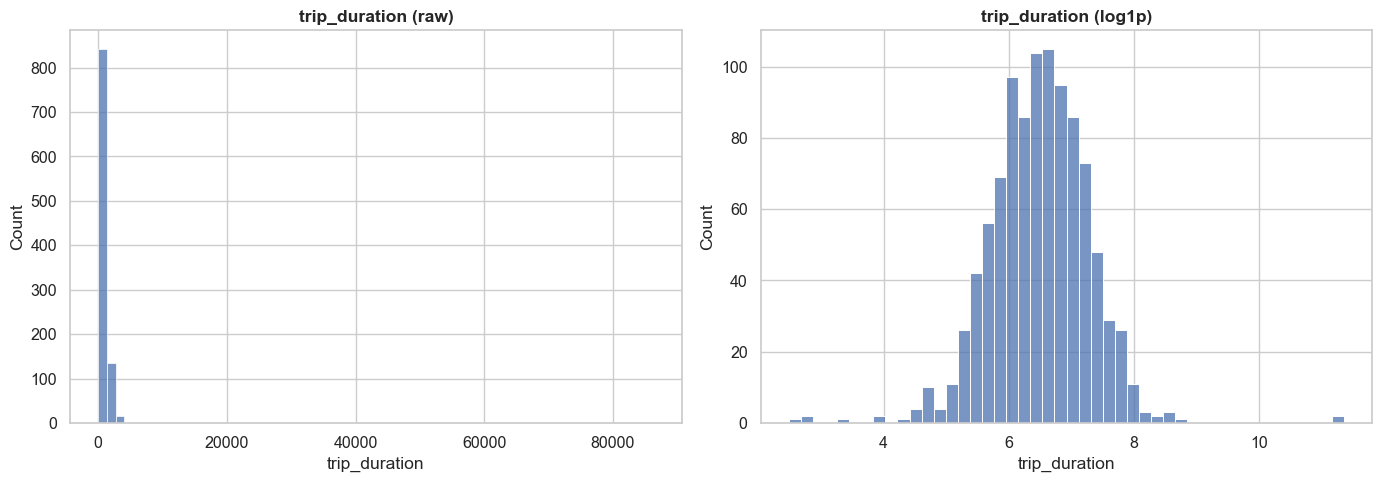

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df, x=df["trip_duration"].head(1000), ax=axes[0])
axes[0].set_title("trip_duration (raw)")

sns.histplot(data=df, x=np.log1p(df["trip_duration"].head(1000)), ax=axes[1])
axes[1].set_title("trip_duration (log1p)")

plt.tight_layout()
plt.show()

The raw distribution is right-skewed. Applying `log1p` brings it much closer to a normal distribution.

## 4. Pickup Volume Over Time

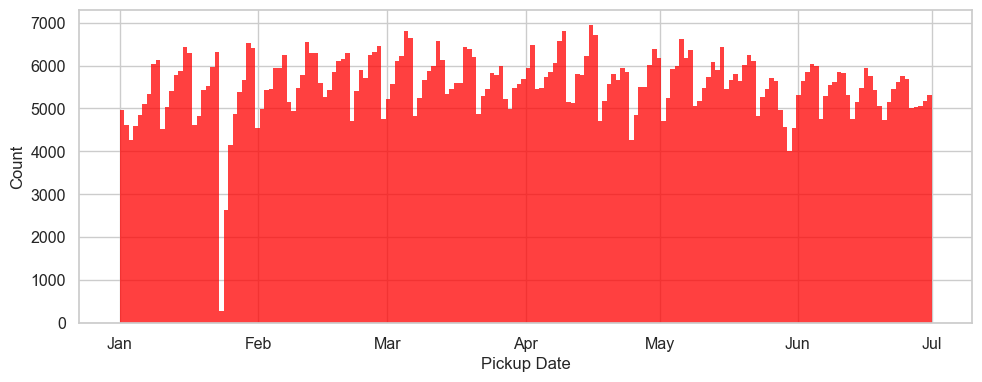

In [6]:
taxi_data = pd.read_csv(
    r"C:\Users\pc\Desktop\Trip duration dataset\split\raw\train.csv",
    usecols=["pickup_datetime"],
    parse_dates=["pickup_datetime"],
    date_format="%Y-%m-%d %H:%M:%S"
)

plt.figure(figsize=(10, 4))
sns.histplot(data=taxi_data, x="pickup_datetime", color="red", bins=180, edgecolor="none")
plt.xlabel("Pickup Date", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b"))
sns.set_style("darkgrid")
plt.tight_layout()
plt.show()

There is a noticeable drop between late January and early February — likely due to bad winter weather.

## 5. Categorical Feature Analysis

### 5.1 Vendor ID

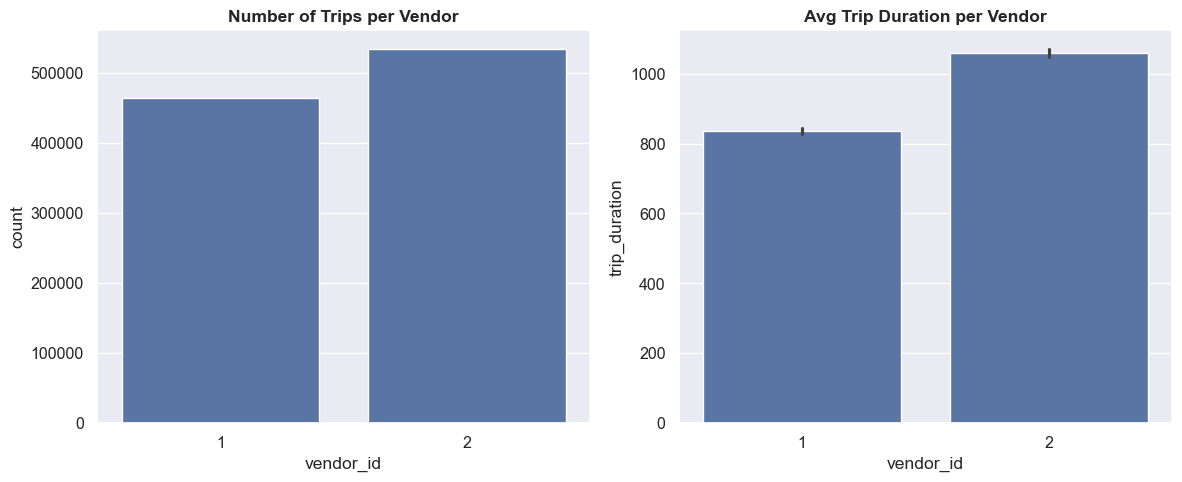

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="vendor_id", ax=axes[0])
axes[0].set_title("Number of Trips per Vendor")

sns.barplot(data=df, x="vendor_id", y="trip_duration", estimator="mean", ax=axes[1])
axes[1].set_title("Avg Trip Duration per Vendor")

plt.tight_layout()
plt.show()

Vendor 2 handles more rides and has longer average trip durations.

### 5.2 Passenger Count

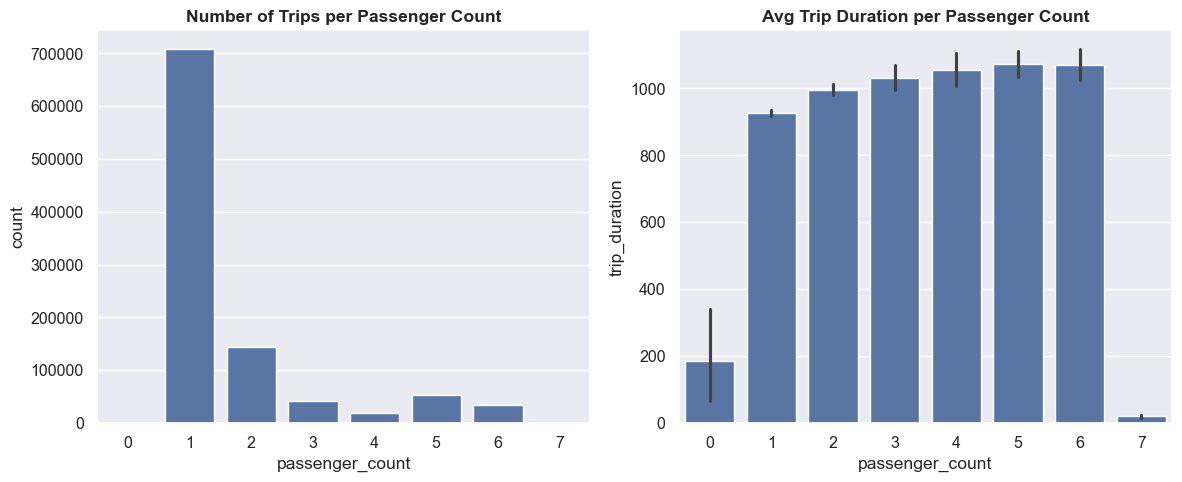

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="passenger_count", ax=axes[0])
axes[0].set_title("Number of Trips per Passenger Count")

sns.barplot(data=df, x="passenger_count", y="trip_duration", ax=axes[1])
axes[1].set_title("Avg Trip Duration per Passenger Count")

plt.tight_layout()
plt.show()

- Single-passenger trips are by far the most common
- Trips with 5–6 passengers tend to be longer
- Some trips have 0 passengers (outliers to remove)

### 5.3 Store & Forward Flag

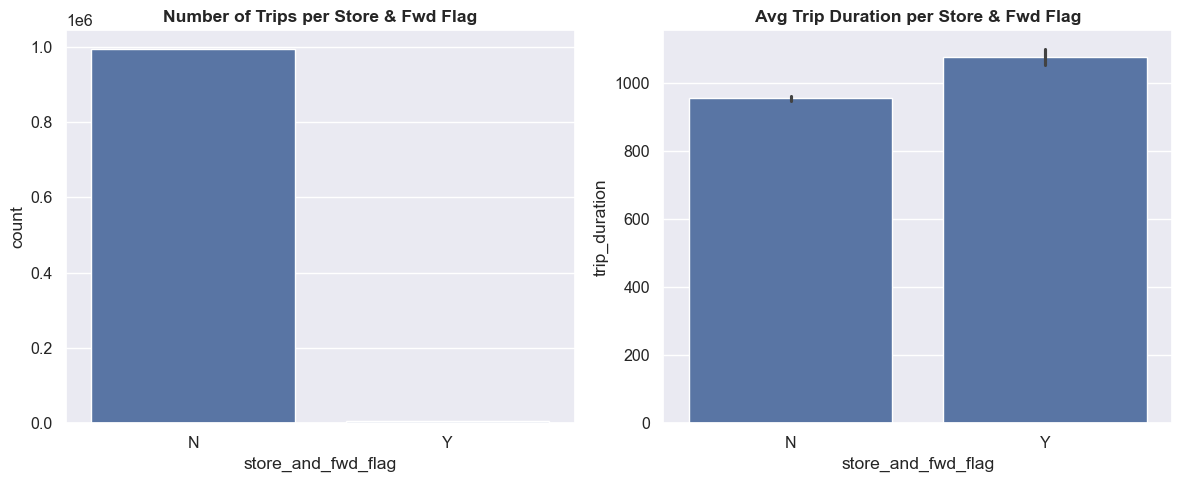

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x="store_and_fwd_flag", ax=axes[0])
axes[0].set_title("Number of Trips per Store & Fwd Flag")

sns.barplot(data=df, x="store_and_fwd_flag", y="trip_duration", ax=axes[1])
axes[1].set_title("Avg Trip Duration per Store & Fwd Flag")

plt.tight_layout()
plt.show()

- Almost all trips are sent in real time (`N`)
- Stored-and-forwarded trips (`Y`) tend to have higher average durations

### 5.4 Trip Duration Outliers by Vendor & Passenger Count

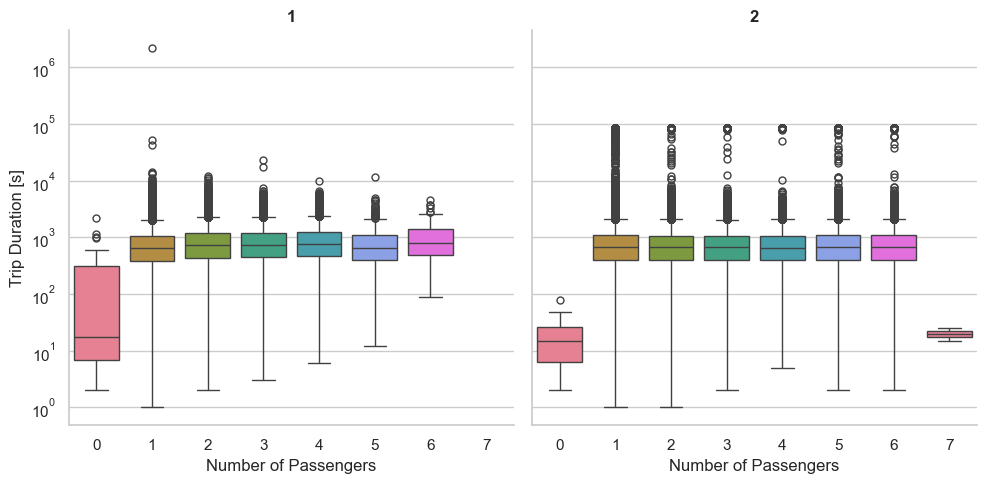

In [10]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=df,
    x="passenger_count",
    y="trip_duration",
    col="vendor_id",
    kind="box",
    hue="passenger_count",
    palette="husl",
    legend=False,
    sharey=True
)
g.set(yscale="log")
g.set_axis_labels("Number of Passengers", "Trip Duration [s]")
g.set_titles("{col_name}")
plt.show()

Vendor 1 has massive outliers exceeding 24 hours (>86,400 seconds). Vendor 2 also shows some near that limit.

## 6. Datetime Feature Analysis

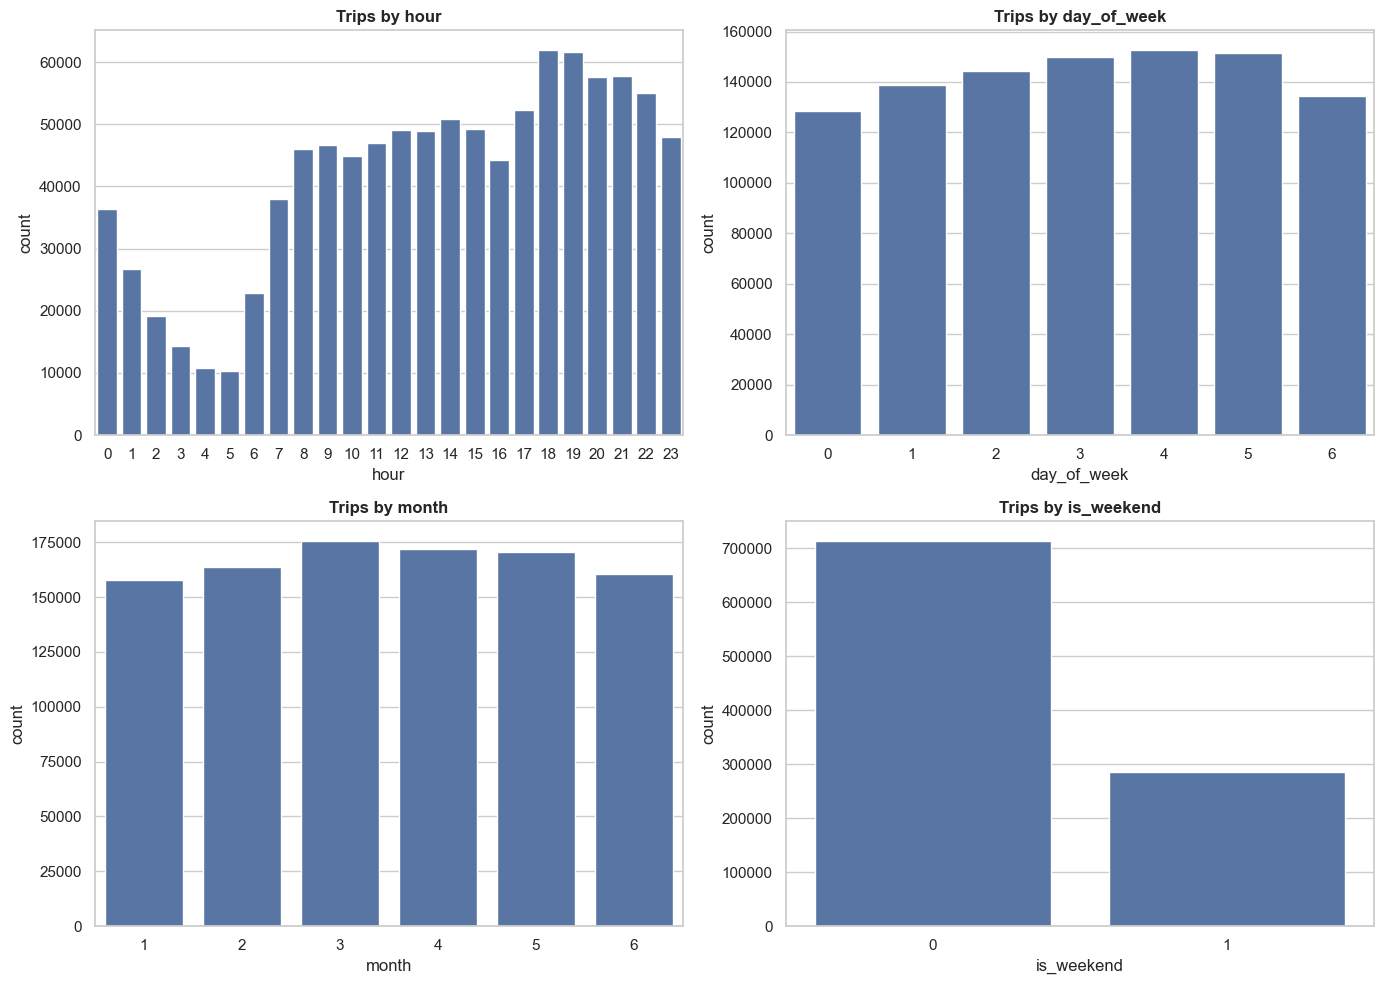

In [11]:
def extract_datetime_features(df, time_col="pickup_datetime"):
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    df["hour"] = df[time_col].dt.hour
    df["day_of_week"] = df[time_col].dt.dayofweek
    df["month"] = df[time_col].dt.month
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    return df

datetime_df = extract_datetime_features(df)

cat_cols = ["hour", "day_of_week", "month", "is_weekend"]
plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(data=datetime_df, x=col)
    plt.title(f"Trips by {col}")
plt.tight_layout()
plt.show()

- **Peak Hours:** Evening spike from 17:00–19:00, secondary morning peak at 08:00. Lowest demand at 03:00–05:00
- **Weekdays vs Weekends:** Most trips happen on weekdays, peaking Thursday–Friday, dropping on Sunday
- **Monthly Volume:** Dataset covers Jan–Jun only; March and April show a slight peak

## 7. Geographical Analysis

### 7.1 Coordinate Scatter (Raw)

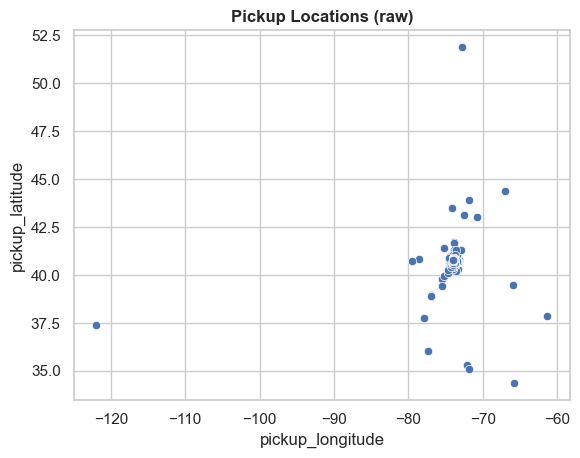

In [12]:
sns.scatterplot(data=df, x="pickup_longitude", y="pickup_latitude")
plt.title("Pickup Locations (raw)")
plt.show()

Clearly visible outliers — we should filter using real NYC coordinate bounds instead of IQR or standard deviation, since these are physical facts.

### 7.2 Coordinate Scatter (Filtered)

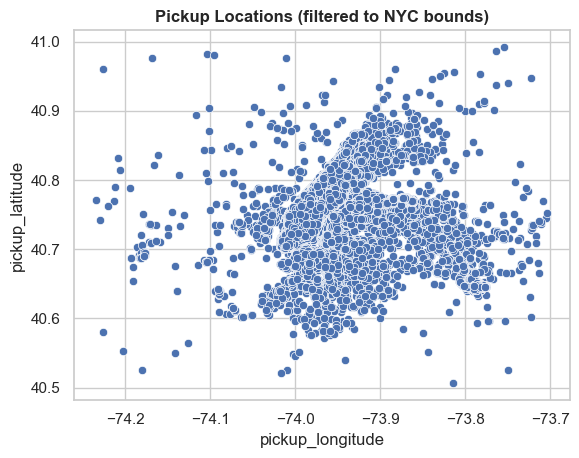

In [13]:
lat_min, lat_max = 40.50, 41.00
lon_min, lon_max = -74.25, -73.70

df = df[
    (df["pickup_latitude"].between(lat_min, lat_max)) &
    (df["dropoff_latitude"].between(lat_min, lat_max)) &
    (df["pickup_longitude"].between(lon_min, lon_max)) &
    (df["dropoff_longitude"].between(lon_min, lon_max))
]

sns.scatterplot(data=df, x="pickup_longitude", y="pickup_latitude")
plt.title("Pickup Locations (filtered to NYC bounds)")
plt.show()

Coordinates now look logical. Two main clusters are visible: Manhattan (highest volume) and JFK.

### 7.3 Interactive Maps

In [14]:
# Pickup map
m_pickup = folium.Map(
    location=[df["pickup_latitude"].mean(), df["pickup_longitude"].mean()],
    zoom_start=12
)
for _, row in df.head(1000).iterrows():
    folium.Marker(
        location=[row["pickup_latitude"], row["pickup_longitude"]],
        popup=f"Trip ID: {row.get('id', 'N/A')}"
    ).add_to(m_pickup)
m_pickup.save("pickup_trip_map.html")
print("Saved: pickup_trip_map.html")

Saved: pickup_trip_map.html


In [15]:
# Dropoff map
m_dropoff = folium.Map(
    location=[df["dropoff_latitude"].mean(), df["dropoff_longitude"].mean()],
    zoom_start=12
)
for _, row in df.head(1000).iterrows():
    folium.Marker(
        location=[row["dropoff_latitude"], row["dropoff_longitude"]],
        popup=f"Trip ID: {row.get('id', 'N/A')}"
    ).add_to(m_dropoff)
m_dropoff.save("dropoff_trip_map.html")
print("Saved: dropoff_trip_map.html")

Saved: dropoff_trip_map.html


## 8. Correlation Heatmap

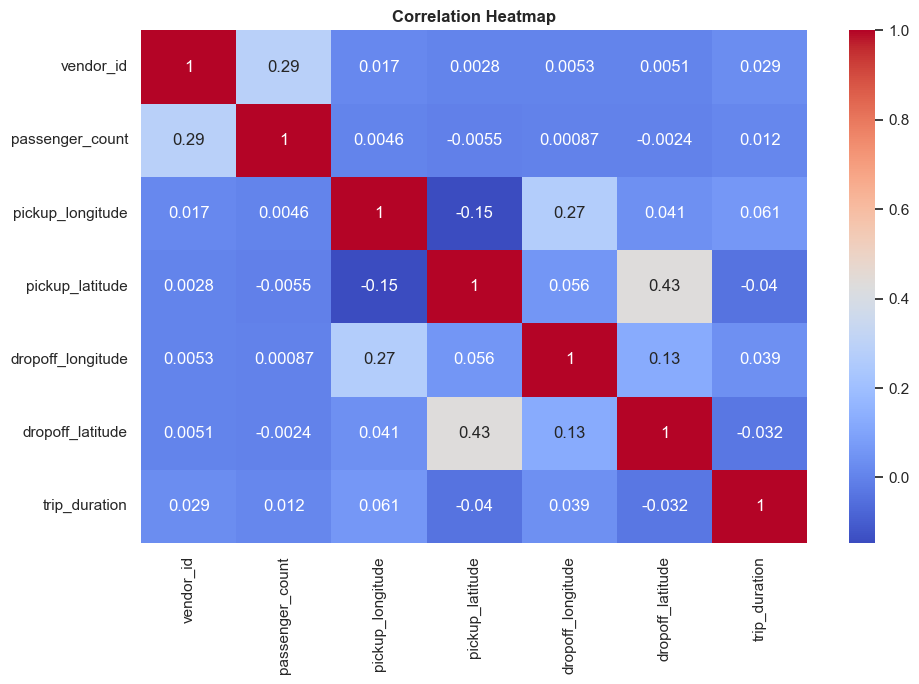

In [16]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 9. Weather EDA

### 9.1 Load & Prepare Weather Data

In [17]:
weather = pd.read_csv(r"C:\Users\pc\Desktop\Trip duration dataset\split\weather\weather_dataset.csv")

# Parse dates
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["date"] = df["pickup_datetime"].dt.date
weather["date"] = pd.to_datetime(weather["date"], format="%d-%m-%Y").dt.date

# Clean trace values
for col in ["precipitation", "snow fall", "snow depth"]:
    weather[col] = weather[col].replace("T", 0.01).astype(float)

# Rename columns
weather = weather.rename(columns={
    "precipitation": "rain",
    "snow fall": "s_fall",
    "snow depth": "s_depth",
    "maximum temperature": "max_temp",
    "minimum temperature": "min_temp"
})

# New features
weather["all_precip"] = weather["rain"] + weather["s_fall"]
weather["has_snow"] = (weather["s_fall"] > 0).astype(int)
weather["has_rain"] = (weather["rain"] > 0).astype(int)

# Merge
weather_features = weather[["date", "rain", "s_fall", "all_precip", "has_snow", "has_rain", "s_depth", "max_temp", "min_temp"]]
df = df.merge(weather_features, on="date", how="left")

C:\Users\pc\AppData\Local\Temp\ipykernel_17352\3742825106.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
C:\Users\pc\AppData\Local\Temp\ipykernel_17352\3742825106.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = df["pickup_datetime"].dt.date


### 9.2 Add Distance & Speed

In [18]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return R * 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(
    df["pickup_latitude"], df["pickup_longitude"],
    df["dropoff_latitude"], df["dropoff_longitude"]
)
df["speed"] = df["distance_km"] / (df["trip_duration"] / 3600)
df = df[(df["speed"] > 0) & (df["speed"] < 120)]

### 9.3 Daily Trips vs Weather

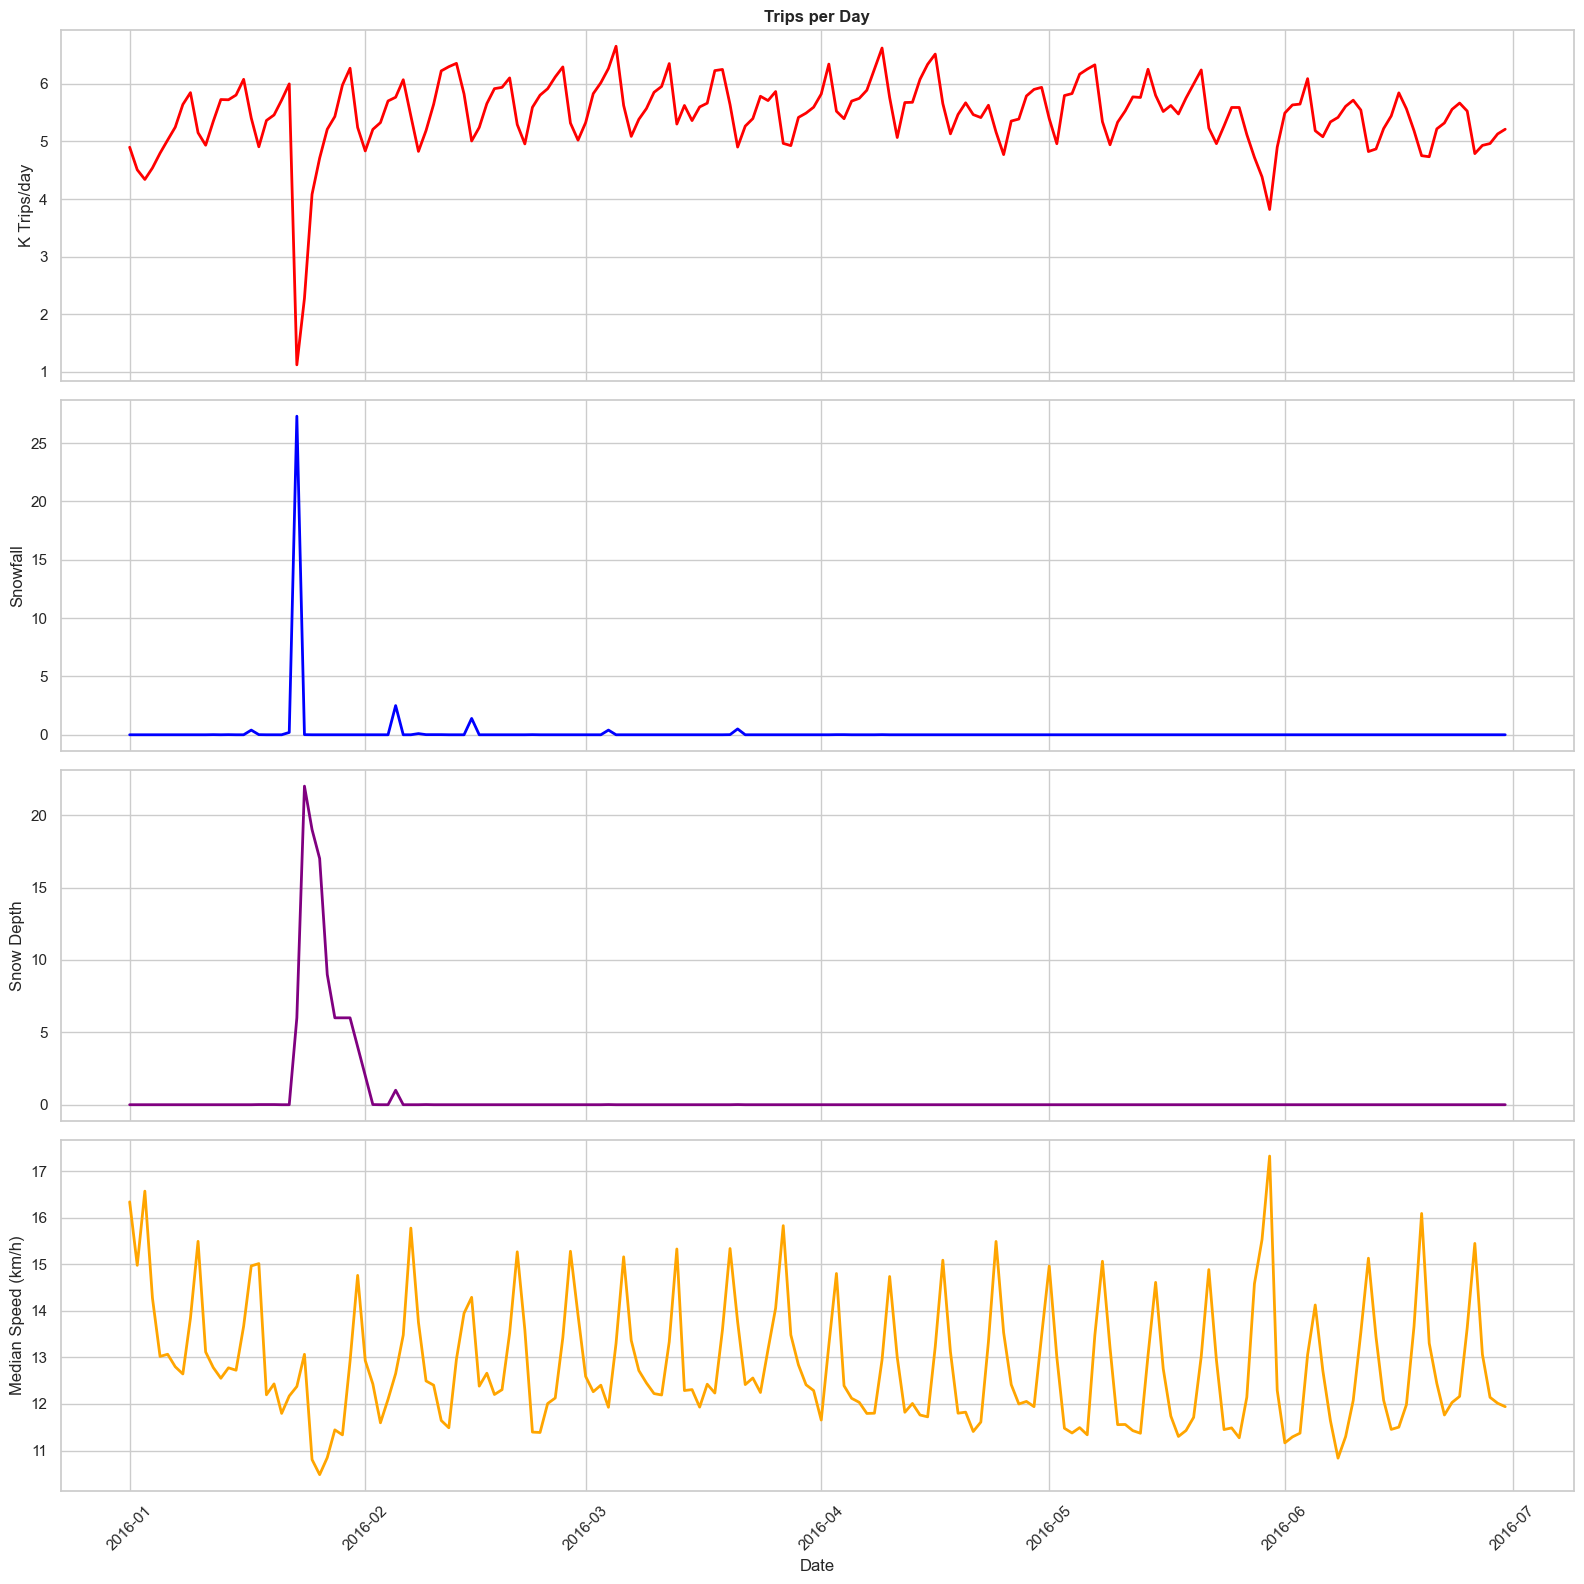

In [19]:
trips = df.groupby("date").size()
daily_weather = (
    df.groupby("date")
      .agg(
          trips=("id", "count"),
          snow_fall=("s_fall", "mean"),
          rain_fall=("rain", "mean"),
          all_precip=("all_precip", "mean"),
          snow_depth=("s_depth", "mean"),
          median_speed=("speed", "median")
      )
)

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

axes[0].plot(trips.index, trips.values / 1000, color="red", linewidth=2)
axes[0].set_ylabel("K Trips/day")
axes[0].set_title("Trips per Day")

axes[1].plot(daily_weather.index, daily_weather["snow_fall"], color="blue", linewidth=2)
axes[1].set_ylabel("Snowfall")

axes[2].plot(daily_weather.index, daily_weather["snow_depth"], color="purple", linewidth=2)
axes[2].set_ylabel("Snow Depth")

axes[3].plot(daily_weather.index, daily_weather["median_speed"], color="orange", linewidth=2)
axes[3].set_ylabel("Median Speed (km/h)")
axes[3].set_xlabel("Date")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 9.4 Precipitation vs Trip Duration

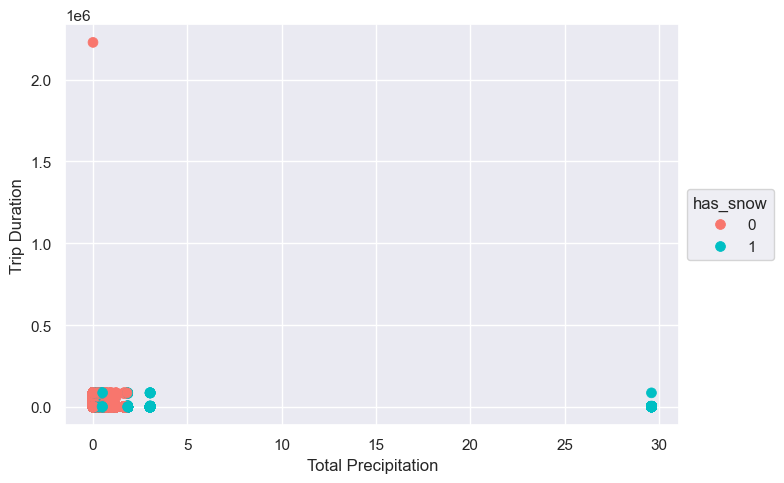

In [20]:
sns.set_style("darkgrid")
plt.figure(figsize=(8, 5))

custom_palette = {False: "#F8766D", True: "#00BFC4"}
sns.scatterplot(
    data=df,
    x="all_precip",
    y="trip_duration",
    hue="has_snow",
    palette=custom_palette,
    s=50,
    edgecolor=None
)
plt.xlabel("Total Precipitation")
plt.ylabel("Trip Duration")
plt.legend(title="has_snow", loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## 10. OSRM Fastest-Route Data

The [OSRM](http://project-osrm.org/) engine provides, for every trip, the *fastest possible route* between pickup and drop-off: its distance, travel time, number of steps (turns/maneuvers), and the turn-by-turn directions. Comparing this idealized route against the taxi's actual `trip_duration` is a great way to spot data-quality issues and genuinely delayed trips.

### 10.1 Loading the Data

In [21]:
fastest_route_1 = pd.read_csv(r"C:\Users\pc\Desktop\Trip duration dataset\split\OSRM\fastest_routes_train_part_1.csv")
fastest_route_2 = pd.read_csv(r"C:\Users\pc\Desktop\Trip duration dataset\split\OSRM\fastest_routes_train_part_2.csv")
fastest_route = pd.concat([fastest_route_1, fastest_route_2], ignore_index=True)
print(f'fastest route 1 shape : {fastest_route_1.shape}')
print(f'fastest route 2 shape : {fastest_route_2.shape}')
print(f'resulted dataset shape : {fastest_route.shape}')
fastest_route.head()

fastest route 1 shape : (700000, 12)
fastest route 2 shape : (758643, 12)
resulted dataset shape : (1458643, 12)


,id,starting_street,end_street,total_distance,total_travel_time,number_of_steps,street_for_each_step,distance_per_step,travel_time_per_step,step_maneuvers,step_direction,step_location_list
0,id2875421,Columbus Circle,East 65th Street,2009.1,164.9,5,Columbus Circle|Central Park West|65th Street ...,0|576.4|885.6|547.1|0,0|61.1|60.1|43.7|0,depart|rotary|turn|new name|arrive,left|straight|right|straight|arrive,"-73.982316,40.767869|-73.981997,40.767688|-73...."
1,id2377394,2nd Avenue,Washington Square West,2513.2,332.0,6,2nd Avenue|East 13th Street|5th Avenue|Washing...,877.3|836.5|496.1|164.2|139.1|0,111.7|109|69.9|25.8|15.6|0,depart|turn|turn|end of road|continue|arrive,none|right|left|right|left|arrive,"-73.980429,40.73857|-73.985444,40.731658|-73.9..."
2,id3504673,Greenwich Street,Broadway,1779.4,235.8,4,Greenwich Street|Park Place|Broadway|Broadway,644.2|379.9|755.3|0,80.5|50.8|104.5|0,depart|turn|end of road|arrive,left|left|right|arrive,"-74.010145,40.719982|-74.011527,40.714294|-74...."
3,id2181028,Broadway,West 81st Street,1614.9,140.1,5,Broadway|West 86th Street|Columbus Avenue|West...,617|427.4|412.2|158.3|0,56|36|37.8|10.3|0,depart|turn|turn|turn|arrive,right|left|right|left|arrive,"-73.972998,40.793187|-73.976607,40.788361|-73...."
4,id0801584,Lexington Avenue,West 31st Street,1393.5,189.4,5,Lexington Avenue|East 27th Street|Madison Aven...,18.9|311.9|313.3|749.4|0,6.3|42.9|48.4|91.8|0,depart|turn|turn|turn|arrive,right|right|right|left|arrive,"-73.982805,40.742173|-73.982914,40.742024|-73...."


### 10.2 Distance, Travel Time & Step Count — Raw Distributions

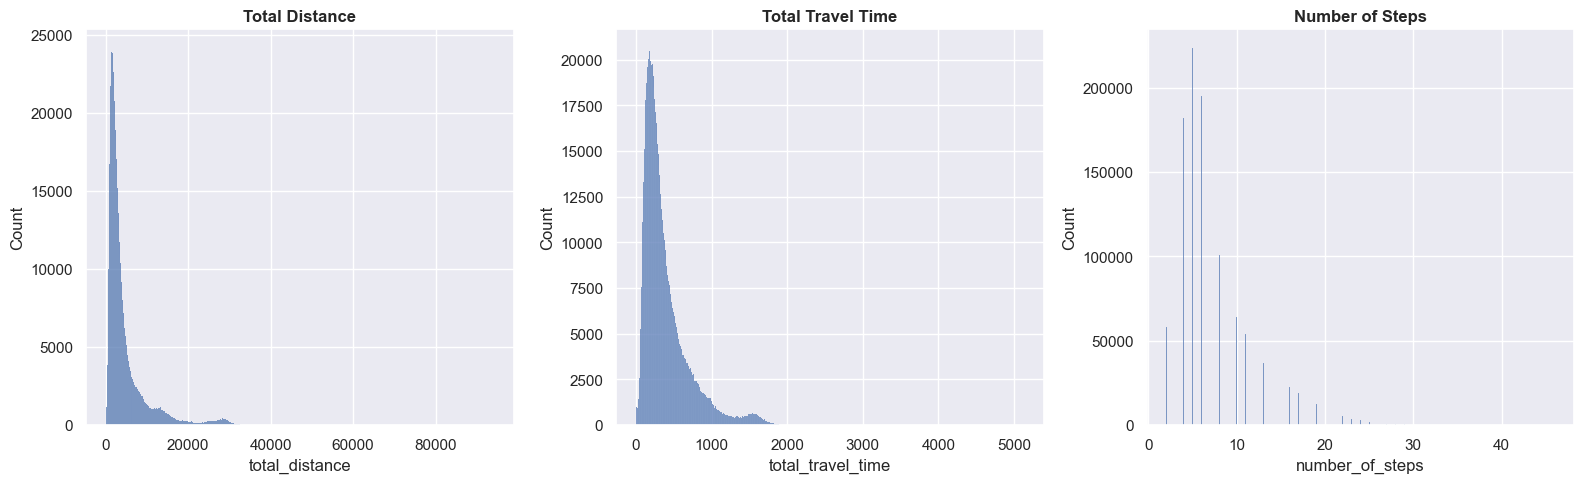

In [22]:
# 1. Expand the canvas size (width=16, height=5)
plt.figure(figsize=(16, 5))

# Subplot 1: Total Distance
plt.subplot(1, 3, 1)
sns.histplot(data=fastest_route, x='total_distance')
plt.title('Total Distance')

# Subplot 2: Total Travel Time
plt.subplot(1, 3, 2)
sns.histplot(data=fastest_route, x='total_travel_time')
plt.title('Total Travel Time')

# Subplot 3: Number of Steps
plt.subplot(1, 3, 3)
sns.histplot(data=fastest_route, x='number_of_steps')
plt.title('Number of Steps')

# 2. Automatically adjust spacing to prevent overlapping text
plt.tight_layout()

plt.show()

### 10.3 Log-Scaled Distributions

The raw distributions above are heavily right-skewed; a log scale makes their shape much easier to read.

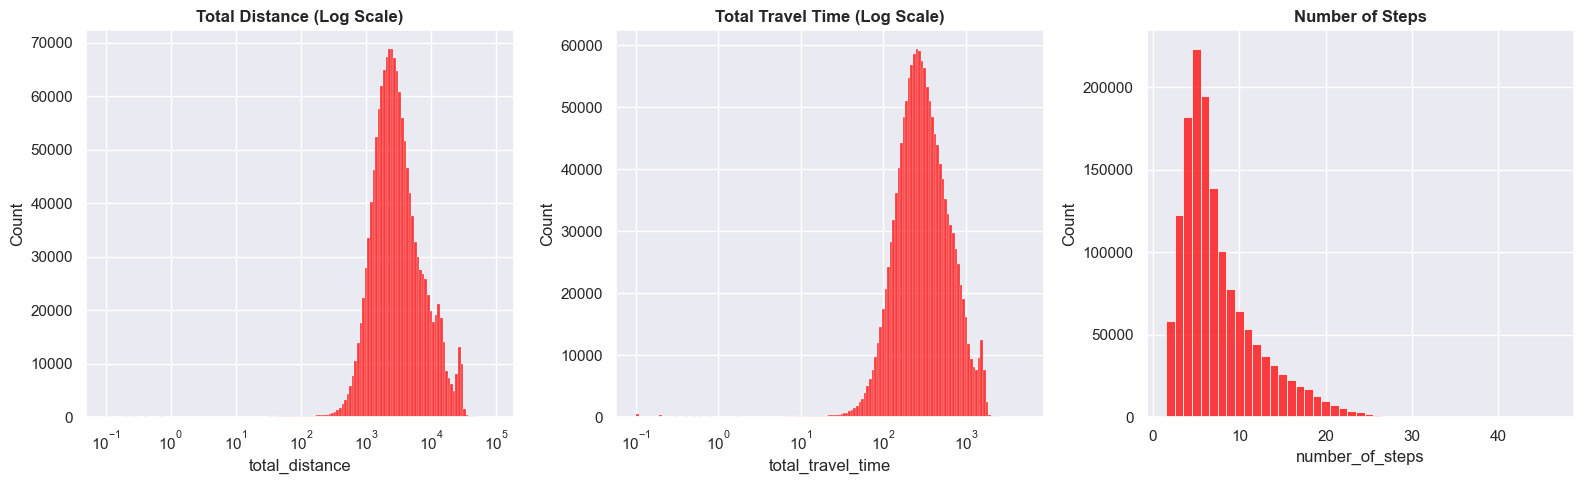

In [23]:
plt.figure(figsize=(16, 5))

# Subplot 1: Total Distance (with Log Scale)
plt.subplot(1, 3, 1)
sns.histplot(data=fastest_route, x='total_distance', bins=150, log_scale=True, color='red')
plt.title('Total Distance (Log Scale)')

# Subplot 2: Total Travel Time (with Log Scale)
plt.subplot(1, 3, 2)
sns.histplot(data=fastest_route, x='total_travel_time', bins=150, log_scale=True, color='red')
plt.title('Total Travel Time (Log Scale)')

# Subplot 3: Number of Steps (Discrete count barplot)
plt.subplot(1, 3, 3)
sns.histplot(data=fastest_route, x='number_of_steps', discrete=True, color='red')
plt.title('Number of Steps')

plt.tight_layout()
plt.show()

Here we applied some log scaling

### 10.4 Number of Steps vs. Travel Time

<Axes: xlabel='number_of_steps', ylabel='total_travel_time'>

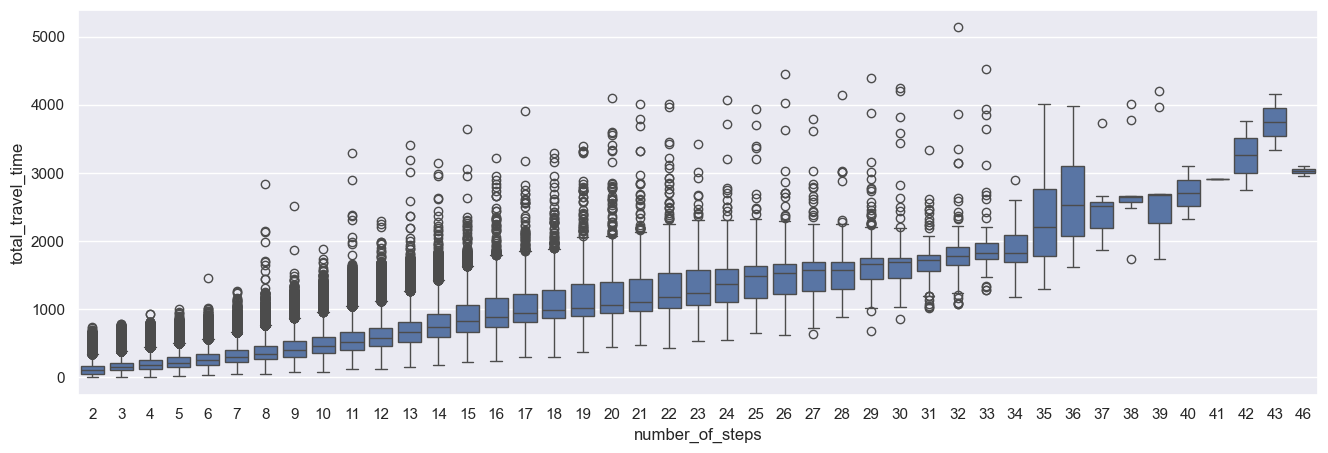

In [24]:
plt.figure(figsize=(16, 5))
sns.boxplot(data = fastest_route , x = 'number_of_steps' , y = 'total_travel_time')

Number of steps correlates with medians of total travel time

### 10.5 Merging OSRM Features into the Main Dataset

We join the OSRM route features onto `df` by trip `id`, and derive a *fast speed* (the average speed implied if the trip had taken exactly `total_distance` / `trip_duration`).

In [25]:
df = (
    df.merge(fastest_route, on="id", how="left")
    .assign(fast_speed_trip = lambda df: (df['total_distance'] / df['trip_duration']) * 3.6)
)

## 11. Trip Duration vs. Total Travel Time — Curious Delays

In this section we compare the OSRM `total_travel_time` (the fastest possible route) to the taxi's actual `trip_duration`, and dig into the cases that look like genuine delays.

### 11.1 Feature Engineering

We need three extra pieces of information that aren't in `df` yet: the share of left turns on each route, standard datetime features, and simple JFK / LaGuardia airport flags.

In [26]:
# Share of left turns on the OSRM route
def count_left_turns(step_direction):
    if pd.isna(step_direction):
        return 0
    return step_direction.split("|").count("left")

df["left_turns"] = df["step_direction"].apply(count_left_turns)
df["left_turn_pct"] = df["left_turns"] / df["number_of_steps"].replace(0, np.nan)

# Datetime features
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df["hour"] = df["pickup_datetime"].dt.hour
df["day_of_week"] = df["pickup_datetime"].dt.dayofweek
df["wday"] = df["pickup_datetime"].dt.day_name()
df["month"] = df["pickup_datetime"].dt.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
df["work_hours"] = df["hour"].between(8, 18).astype(int)

# Simple airport flags (great-circle distance to JFK / LaGuardia terminals)
JFK, LGA, AIRPORT_RADIUS_KM = (40.6413, -73.7781), (40.7769, -73.8740), 1.5

def near_airport(lat, lon, center, radius_km=AIRPORT_RADIUS_KM):
    return haversine(lat, lon, center[0], center[1]) < radius_km

df["jfk_trip"] = (
    near_airport(df["pickup_latitude"], df["pickup_longitude"], JFK)
    | near_airport(df["dropoff_latitude"], df["dropoff_longitude"], JFK)
)
df["lg_trip"] = (
    near_airport(df["pickup_latitude"], df["pickup_longitude"], LGA)
    | near_airport(df["dropoff_latitude"], df["dropoff_longitude"], LGA)
)

df[["left_turns", "left_turn_pct", "jfk_trip", "lg_trip"]].describe(include="all")

,left_turns,left_turn_pct,jfk_trip,lg_trip
count,995200.000000,995199.000000,995200,995200
unique,NaN,NaN,2,2
top,NaN,NaN,False,False
freq,NaN,NaN,966965,958103
mean,1.858892,0.260882,NaN,NaN
std,1.319106,0.174048,NaN,NaN
min,0.000000,0.000000,NaN,NaN
25%,1.000000,0.142857,NaN,NaN
50%,2.000000,0.250000,NaN,NaN
75%,3.000000,0.375000,NaN,NaN


### 11.2 The Big Picture: `trip_duration` vs. `total_travel_time`

Both axes are log-scaled; the red line marks `trip_duration = total_travel_time`, and the dashed lines mark `total_travel_time` = 50 s and 2000 s — the window we'll zoom into next. Points are colored by the share of left turns on the route.

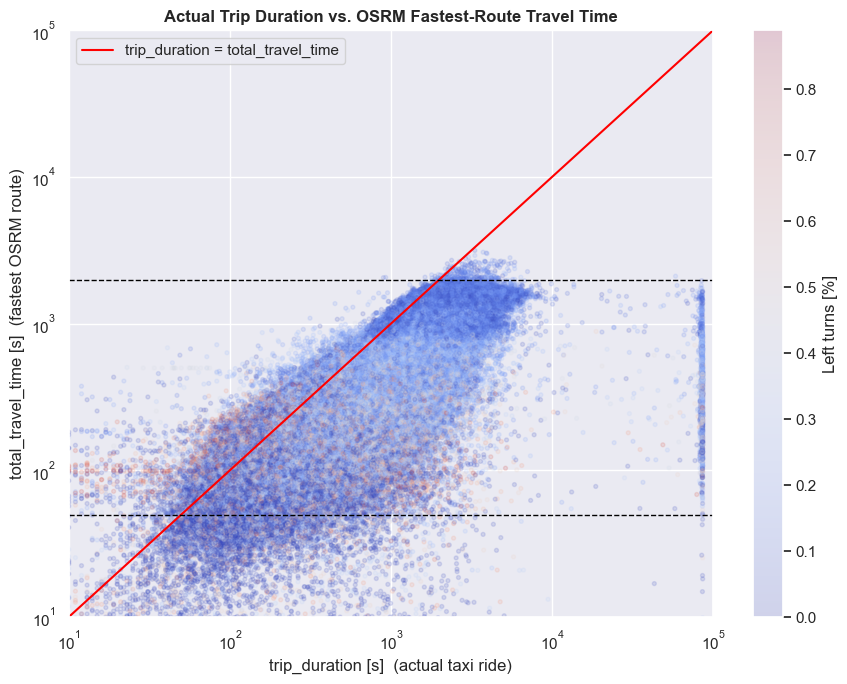

In [27]:
plt.figure(figsize=(9, 7))
sc = plt.scatter(
    df["trip_duration"], df["total_travel_time"],
    c=df["left_turn_pct"], cmap="coolwarm", alpha=0.15, s=8
)
lims = [10, 1e5]
plt.plot(lims, lims, color="red", lw=1.5, label="trip_duration = total_travel_time")
plt.axhline(50, color="black", linestyle="--", lw=1)
plt.axhline(2000, color="black", linestyle="--", lw=1)
plt.xscale("log")
plt.yscale("log")
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("trip_duration [s]  (actual taxi ride)")
plt.ylabel("total_travel_time [s]  (fastest OSRM route)")
plt.title("Actual Trip Duration vs. OSRM Fastest-Route Travel Time")
cbar = plt.colorbar(sc)
cbar.set_label("Left turns [%]")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Findings**

- A cluster of trips has `trip_duration` noticeably *lower* than `total_travel_time`. The gap is largest for routes under roughly 1000 s (~17 min) and shrinks for longer routes.
- OSRM's fastest-route estimate almost never exceeds ~10,000 s (the observed max sits around 5,000 s / 1.5 h). The long-delay outliers — between the dashed lines, extending past 10,000 s of actual duration — sit in a `total_travel_time` window of roughly 100–2000 s.
- Routes with more steps tend to include a higher share of left turns, but this could just reflect that very short trips have no turns at all. Within the long-delay outliers specifically, the turn fraction shows no obvious pattern.

### 11.3 Isolating the Long-Delay Outliers (50 s < `total_travel_time` < 2000 s)

We restrict to the window flagged above and label a trip as a "delay" if its `trip_duration` exceeds 10,000 s (~2.8 h) despite OSRM estimating a short route.

In [28]:
delay_window = df[df["total_travel_time"].between(50, 2000)].copy()
delay_window["delay"] = delay_window["trip_duration"] > 1e4

delay_window.groupby("delay").size().rename("n_trips").to_frame()

,n_trips
delay,
False,983497
True,1439


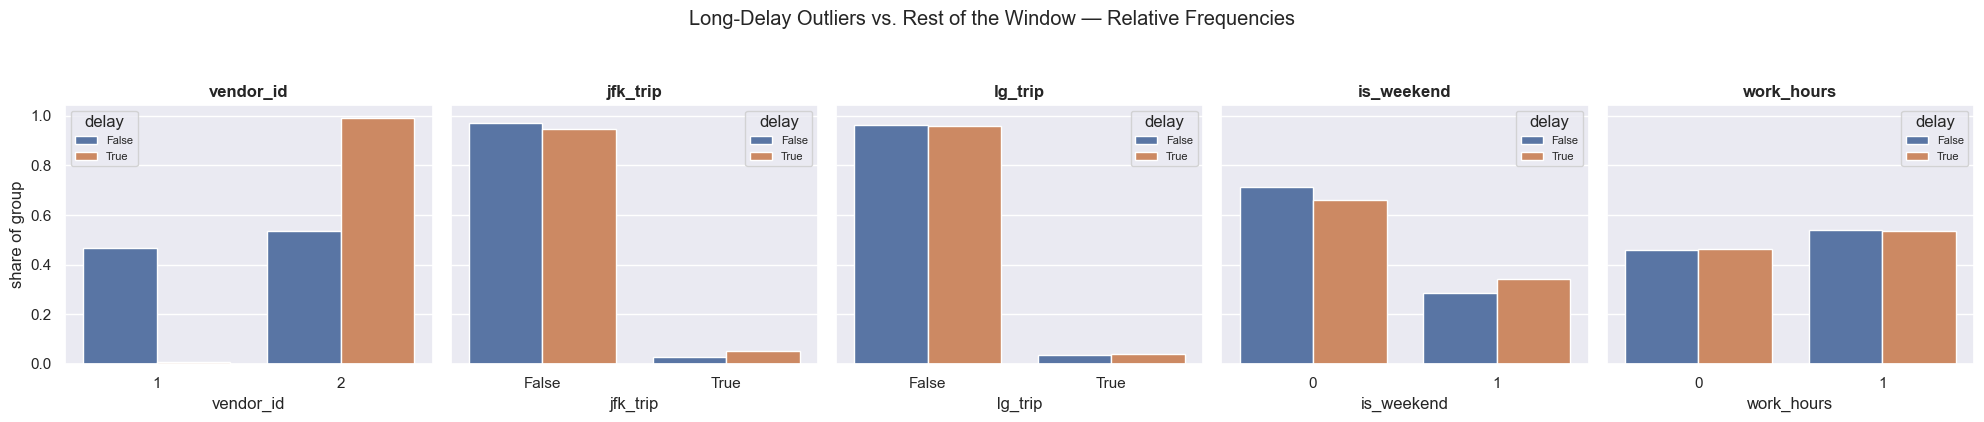

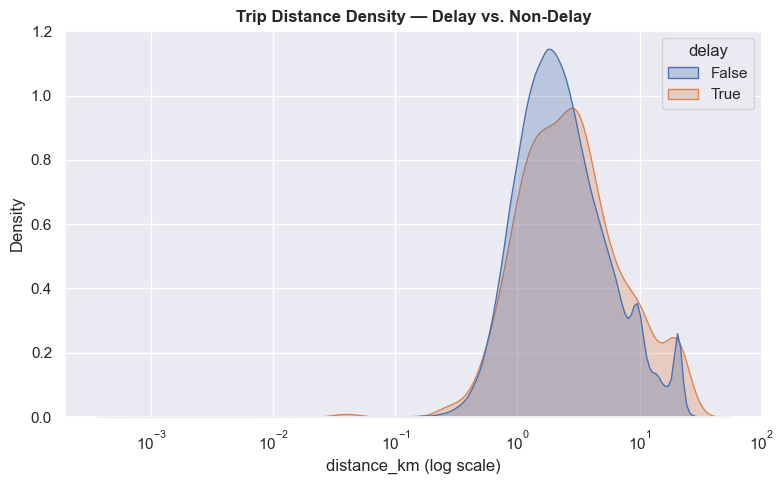

In [29]:
compare_cols = ["vendor_id", "jfk_trip", "lg_trip", "is_weekend", "work_hours"]

fig, axes = plt.subplots(1, len(compare_cols), figsize=(20, 4), sharey=True)
for ax, col in zip(axes, compare_cols):
    shares = (
        delay_window.groupby("delay")[col]
        .value_counts(normalize=True)
        .rename("share")
        .reset_index()
    )
    sns.barplot(data=shares, x=col, y="share", hue="delay", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("share of group" if ax is axes[0] else "")
    ax.legend(title="delay", fontsize=8)

plt.suptitle("Long-Delay Outliers vs. Rest of the Window — Relative Frequencies", y=1.05)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.kdeplot(
    data=delay_window, x="distance_km", hue="delay",
    common_norm=False, log_scale=True, fill=True, alpha=0.3
)
plt.title("Trip Distance Density — Delay vs. Non-Delay")
plt.xlabel("distance_km (log scale)")
plt.tight_layout()
plt.show()

**Findings**

- Long delays are heavily concentrated in **vendor 2**, out of proportion to vendor 2's overall share of trips — this alone explains most of the effect.
- Airport trips are over-represented in the delay group, especially JFK. A plausible explanation is that `trip_duration` includes the time spent queuing for passengers at the airport, which OSRM's routing model has no way to see.
- The delay group skews toward *longer* trip distances than the rest of the window, even though every trip being compared shares a similar `total_travel_time` bracket.
- Weekday, month, and work-hours differences are small (a few percentage points at most) and are plausibly just noise given how many categories were checked.

### 11.4 A Second Outlier Group: Short Routes, Long Durations

There's a second, distinct group in the lower-middle of the scatter plot: routes OSRM thinks take *less than 10 seconds*, but that the taxi meter recorded as 600–4000 s (10 min – 1.1 h).

Short-route delay outliers: 273 trips


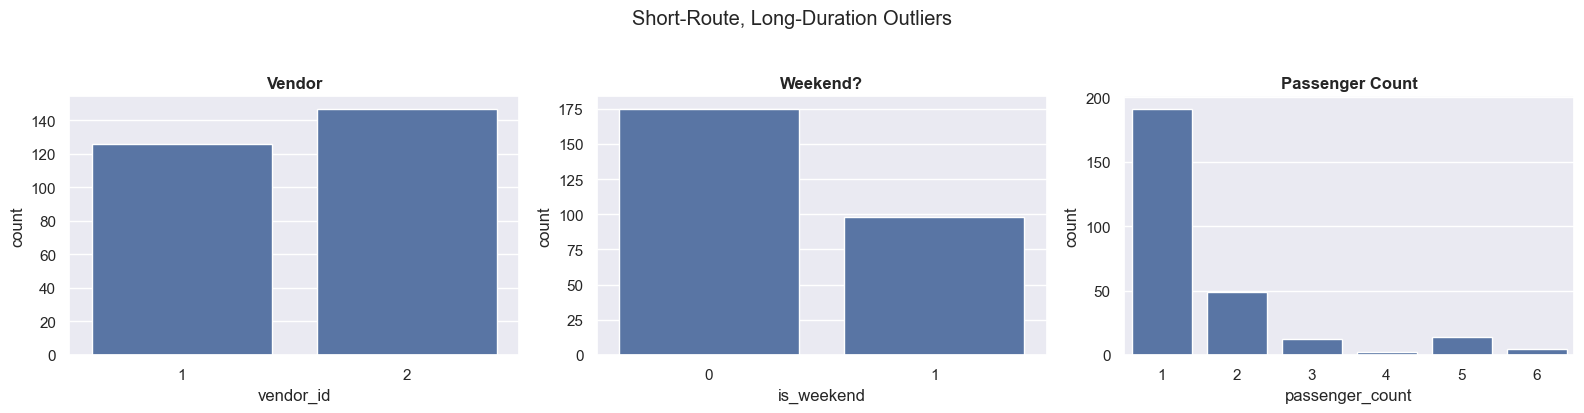

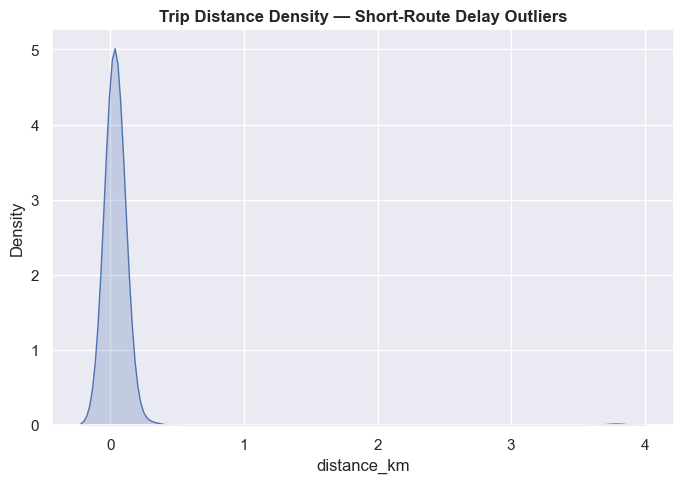

In [30]:
short_route_delay = df[
    (df["total_travel_time"] < 10) & (df["trip_duration"].between(600, 4000))
].copy()

print(f"Short-route delay outliers: {len(short_route_delay):,} trips")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=short_route_delay, x="vendor_id", ax=axes[0])
axes[0].set_title("Vendor")
sns.countplot(data=short_route_delay, x="is_weekend", ax=axes[1])
axes[1].set_title("Weekend?")
sns.countplot(data=short_route_delay, x="passenger_count", ax=axes[2])
axes[2].set_title("Passenger Count")
plt.suptitle("Short-Route, Long-Duration Outliers", y=1.03)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
sns.kdeplot(data=short_route_delay, x="distance_km", fill=True)
plt.title("Trip Distance Density — Short-Route Delay Outliers")
plt.xlabel("distance_km")
plt.tight_layout()
plt.show()

**Findings**

- Vendor 2 again dominates this second outlier group, echoing the pattern from the first one.
- These delays skew slightly toward weekends.
- Passenger count runs a bit higher than average, hinting that boarding/alighting time (extra riders, luggage) may explain part of the gap.
- Trip distances are longer than a genuinely near-zero-distance ride should be — though on a very different scale than the first outlier group, since a route this short shouldn't take more than a couple of minutes at most.

### 11.5 Summary

- `vendor_id` is the strongest single signal separating both outlier groups from the rest of the data.
- Airport pickups/drop-offs (especially JFK) are disproportionately represented among the long-`total_travel_time` delays — plausibly because `trip_duration` includes taxi-queue waiting time that OSRM cannot model.
- Weekday, month, and time-of-day show only weak, likely-noisy differences.
- Both outlier groups are a tiny fraction of the overall data (only a few hundred trips out of ~1.4M), but they're worth flagging, capping, or excluding before using `trip_duration` as a raw modeling target.

## 12. Key Takeaways

- **Target variable**: `trip_duration` is strongly right-skewed; a `log1p` transform makes it close to normal and is the natural choice for modeling.
- **Vendors**: vendor 2 consistently shows longer average durations and, as Section 11 shows, contributes almost all of the extreme delay outliers.
- **Time patterns**: demand peaks in the evening (17:00–19:00) with a smaller morning peak, and dips sharply overnight; a late-January/early-February dip lines up with winter weather.
- **Geography**: pickups cluster heavily in Manhattan, with a clear secondary cluster at JFK — and JFK trips are disproportionately represented among the long-delay outliers.
- **OSRM comparison**: the fastest-route estimate is a good baseline, but real trips regularly run longer — most of that gap is explained by vendor, and a meaningful chunk by airport queuing time.
- **Data quality**: a handful of trips (a few hundred out of ~1.4M) have durations that are implausible given the routing and distance data; these are good candidates for capping or removal before modeling.